Import Libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
tf.__version__

'2.20.0'

Import Dataset

In [3]:
dataset = pd.read_csv('housing.csv')

Variables

In [4]:
longitude = dataset['longitude']
latitude = dataset['latitude']
housing_median_age = dataset['housing_median_age']
total_rooms = dataset['total_rooms']
total_bedrooms = dataset['total_bedrooms'] # do I use this variable?
population = dataset['population']
households = dataset['households']
median_income = dataset['median_income']
median_house_value = dataset['median_house_value']
ocean_proximity = dataset['ocean_proximity']  #categorical data for classification analysis

#change value name for readability
dataset['ocean_proximity'] = dataset['ocean_proximity'].replace({
    '<1H OCEAN': 'Less than 1 Hour Ocean'
})
#To remove NaN preditions and errors. Takes missing bedroom value and replaced them with the median bedroom value.
dataset['total_bedrooms'] = dataset['total_bedrooms'].fillna(dataset['total_bedrooms'].median())

# convert category ocean proximity to numreric dummy variable.
dataset = pd.get_dummies(dataset, columns=['ocean_proximity'])
print(dataset.columns)


x = dataset[['longitude',
             'latitude',
             'housing_median_age',
             'total_rooms',
             'total_bedrooms',
             'population',
             'households',
             'median_income',
             'ocean_proximity_INLAND',
             'ocean_proximity_ISLAND',
             'ocean_proximity_Less than 1 Hour Ocean',
             'ocean_proximity_NEAR BAY',
             'ocean_proximity_NEAR OCEAN']]

            #do not incule ocean_proximity since it is categorical

y = dataset['median_house_value']

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_Less than 1 Hour Ocean',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')


In [5]:
print(x)
print(y)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  households  median_income  ocean

Correlation and Heatmap

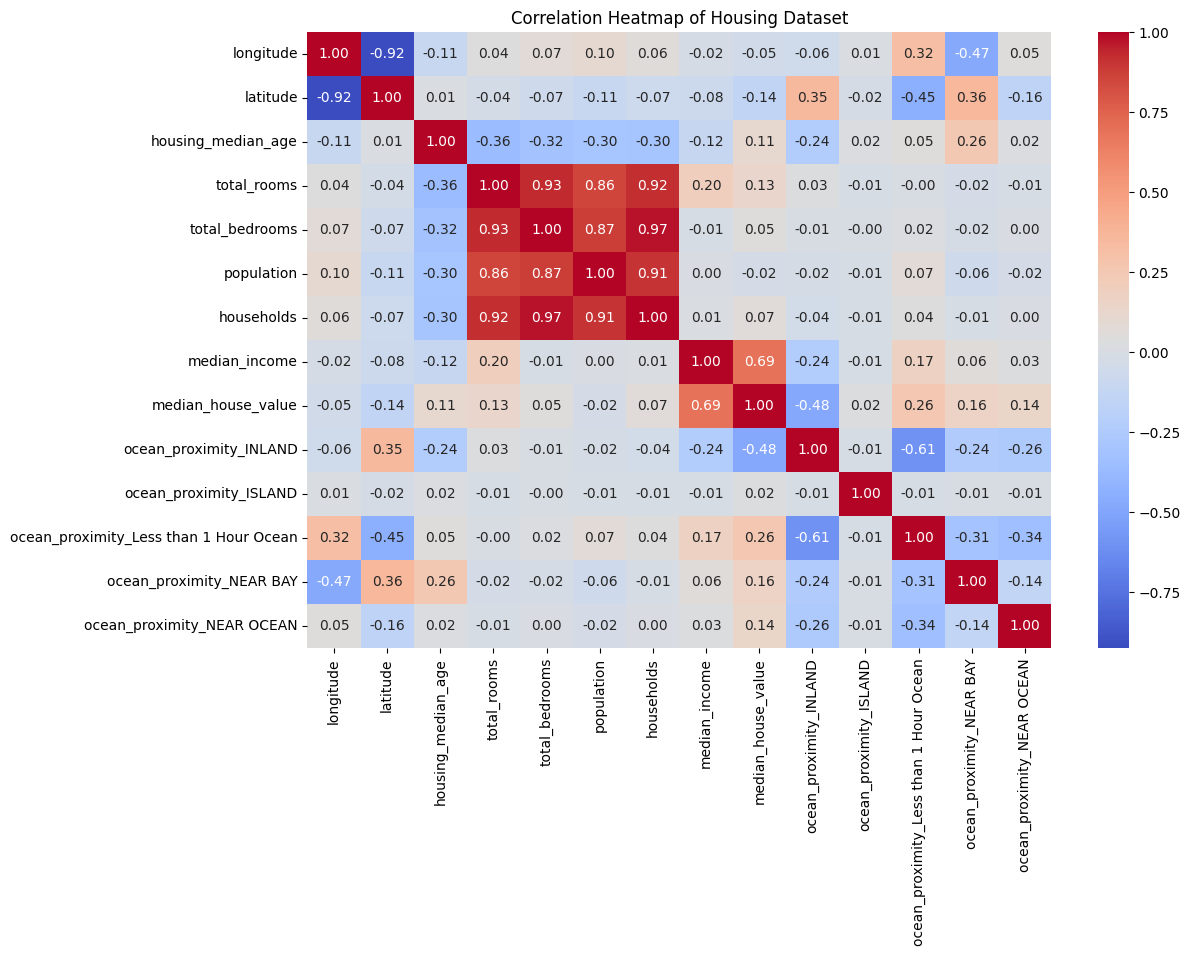

In [6]:
plt.figure(figsize=(12,8))

sns.heatmap(
    dataset.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Housing Dataset")
plt.show()

In [7]:
print(dataset.isnull().sum())

longitude                                 0
latitude                                  0
housing_median_age                        0
total_rooms                               0
total_bedrooms                            0
population                                0
households                                0
median_income                             0
median_house_value                        0
ocean_proximity_INLAND                    0
ocean_proximity_ISLAND                    0
ocean_proximity_Less than 1 Hour Ocean    0
ocean_proximity_NEAR BAY                  0
ocean_proximity_NEAR OCEAN                0
dtype: int64


Splitting Dataset Into Training and Testing

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0) #20% obesrvations in test set

Build Artificial Neural Network (ANN)

In [9]:
ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(units=6, activation='relu')) #adding an input layer and first hidden layer

In [10]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu')) #adding a second hidden layer

In [11]:
ann.add(tf.keras.layers.Dense(units=1)) #adding an output layer
#ann.add(tf.keras.layers.Dense(units=1, activation='relu')) #include activation funtion only in classification

Training ANN

In [12]:
ann.compile(optimizer = 'adam', loss = 'mean_squared_error') #compile ann
ann.fit(x_train, y_train, batch_size = 32, epochs = 100)

Epoch 1/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 52274761728.0000
Epoch 2/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 29870209024.0000
Epoch 3/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 26608416768.0000
Epoch 4/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 26201892864.0000
Epoch 5/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25816164352.0000
Epoch 6/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25382330368.0000
Epoch 7/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 24956635136.0000
Epoch 8/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 24465860608.0000
Epoch 9/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 23952760832.0000
Epoch 10/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 23369242624.0000
Epoch 11/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 22708785152.0000
Epoch 12/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21979023360.0000
Epoch 13/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss:

In [13]:
# predict results of test set
y_pred = ann.predict(x_test)

results = pd.DataFrame({
    'Predicted': y_pred.flatten(),
    'Actual': y_test.values
})

pd.options.display.float_format = '{:.2f}'.format
print(results)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
      Predicted    Actual
0     139149.12 136900.00
1     255920.00 241300.00
2     197209.69 200700.00
3     167440.30  72500.00
4     255398.84 460000.00
...         ...       ...
4123  171410.06 169500.00
4124  213677.00 204600.00
4125  154048.03 128600.00
4126  287998.50 259500.00
4127  180330.12 167600.00

[4128 rows x 2 columns]


Scatterplot for ANN

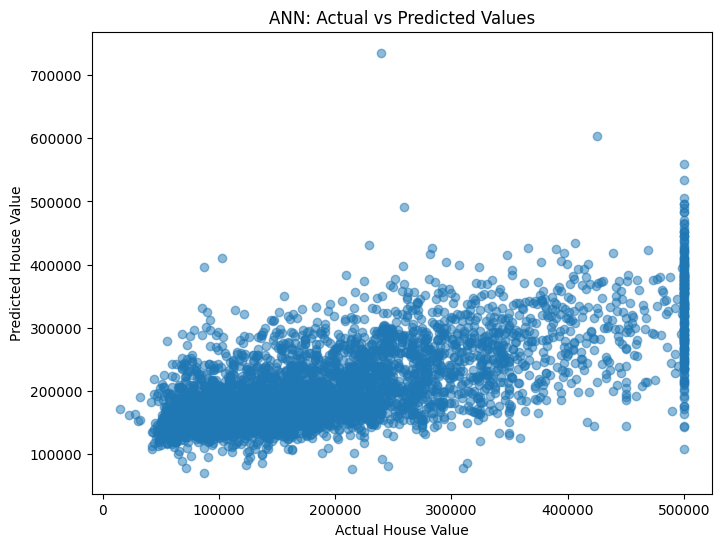

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("ANN: Actual vs Predicted Values")

plt.show()

Plot Mean Squared Error during ANN raining

In [15]:
history = ann.fit(x_train, y_train,
                  batch_size=32,
                  epochs=100,
                  validation_split=0.2)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7223463424.0000 - val_loss: 7096983552.0000
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7190966272.0000 - val_loss: 7079741952.0000
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7160606208.0000 - val_loss: 7036688896.0000
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7130055168.0000 - val_loss: 7013850112.0000
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7094427648.0000 - val_loss: 7010736128.0000
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7060493824.0000 - val_loss: 6953835520.0000
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7024922112.0000 - val_loss: 6922959872.0000
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6995246592.0000 - val_loss: 6883918336.0000
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6973869056.0000 - val_loss: 6859992064.0000
Epoch 10/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step -

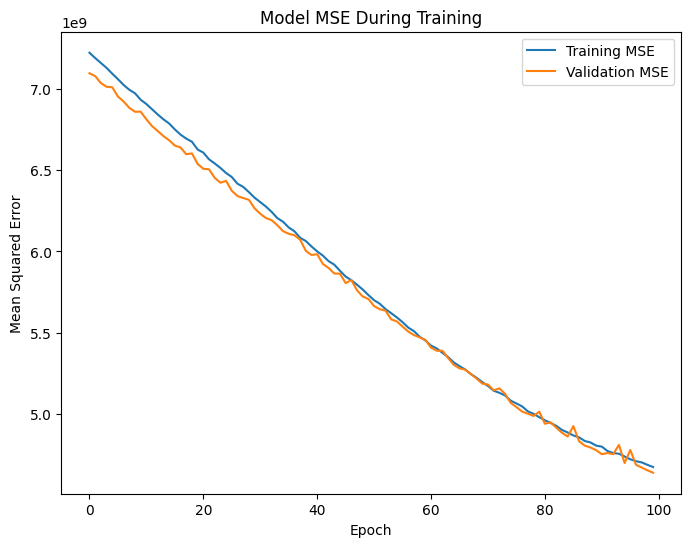

In [16]:
plt.figure(figsize=(8,6))

plt.plot(history.history['loss'], label='Training MSE')
plt.plot(history.history['val_loss'], label='Validation MSE')

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Model MSE During Training")
plt.legend()

plt.show()

R² from predictions

In [17]:
r2 = r2_score(y_test, y_pred)
print("R-squared:", round(r2,4))

R-squared: 0.4386


Random Forest - Training

In [18]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=0,
    n_jobs=-1
)

rf.fit(x_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=0)

Predict and Evaluate

In [19]:
y_pred_rf = rf.predict(x_test)

r2 = r2_score(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest R²:", round(r2,4))
print("RMSE:", round(rmse,2))
print("MAE:", round(mae,2))

Random Forest R²: 0.8239
RMSE: 47914.77
MAE: 31414.97


Scatterplot for Random Forest

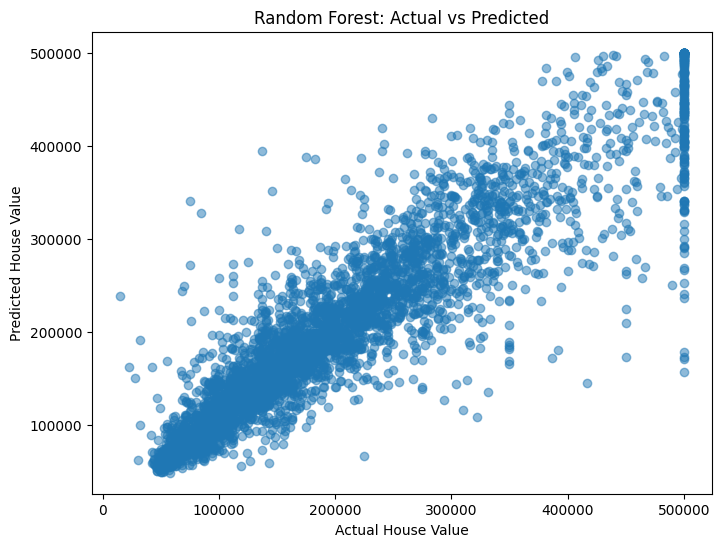

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

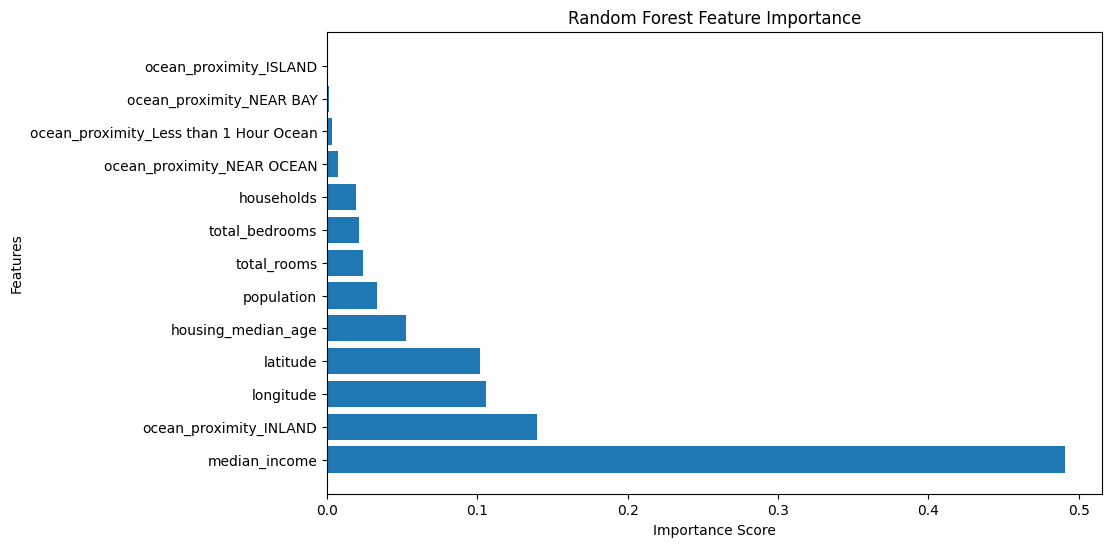

In [21]:
# feature importance from Random Forest
importance = rf.feature_importances_

# create table
feat_imp = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importance
})

# sort highest first
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Draw chart
plt.figure(figsize=(10,6))

plt.barh(feat_imp['Feature'], feat_imp['Importance'])

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.show()